# Stage 4 — visibility-domain mass recovery

Stage 3-1が保存した複素visibilityを直接fitする。
- 各fit内は`dynesty_workers_per_fit` threadsでさらに並列化できる（threadごとに専用のUVContext/FINUFFT planを構築する）。


In [1]:
import os

# case/model fitをprocess並列化するため、各process内のnested threadingは止める。
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

from itertools import product
from pathlib import Path
import multiprocessing as mp
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from astropy.stats import mad_std
from astropy.table import Table
from cmcrameri import cm
from dynesty import plotting as dyplot

%matplotlib inline

EXAMPLE_DIR = Path.cwd().resolve()
if EXAMPLE_DIR.name == 'examples':
    EXAMPLE_DIR = EXAMPLE_DIR / 'forward_mass'
if not (EXAMPLE_DIR.name == 'forward_mass' and EXAMPLE_DIR.parent.name == 'examples'):
    raise FileNotFoundError('Run this notebook from examples/forward_mass or examples.')
if str(EXAMPLE_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLE_DIR))

from glint.caching import load_cached_result, save_cached_result
from glint.inference import (
    make_visibility_loglikelihood,
    run_dynamic_dynesty_parallel,
    weighted_quantile,
)
from glint.interferometer import vis_to_image_finufft_type3
from glint.uv_processing import load_processed_uv
import forward_mass_common as fmc


## Configuration and numerical grids

`mock_truth.toml`からmockの真値とgridを、`mock_stage4.toml`からStage 4 fit独自の 設定を読む

In [2]:
TRUTH_CONFIG = fmc.load_toml(EXAMPLE_DIR / 'mock_truth.toml')
CONFIG = fmc.load_toml(EXAMPLE_DIR / 'mock_stage4.toml')

uv_cfg = CONFIG['uv_fit']
dynesty_cfg = CONFIG['dynesty']
parallel_cfg = CONFIG['parallel']
DYNESTY_WORKERS_PER_FIT = int(parallel_cfg.get('dynesty_workers_per_fit', 1))

STAGE1_PRODUCT_DIR = EXAMPLE_DIR / 'output' / 'stage1' / 'products'
STAGE3_PRODUCT_DIR = EXAMPLE_DIR / 'output' / 'stage3' / 'products'
CASA_WORK_DIR = EXAMPLE_DIR / 'output' / 'stage3' / 'casa_work'
OUTPUT_DIR = EXAMPLE_DIR / 'output' / 'stage4' / 'results'
CACHE_DIR = OUTPUT_DIR / 'cache'
FIGURE_DIR = OUTPUT_DIR / 'figures'
for directory in (CACHE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# fitの間固定な状態（grids・radius・velocity channels ...）を ForwardModelへ一括構築する。beamは不要。
MODEL = fmc.build_forward_model(
    TRUTH_CONFIG, CONFIG,
    # 3-1はline-free端channelをexportしないので、fitのchannel gridも同数削る。
    drop_edge_channels=int(CONFIG['uv_fit']['line_free_edge_channels']),
)
MODEL_FREE_NAMES = {
    'bulge': tuple(CONFIG['fit']['free_parameters_bulge']),
    'no_bulge': tuple(CONFIG['fit']['free_parameters_no_bulge']),
}
BOUNDS = CONFIG['fit']['bounds']

print(f'image cube: {MODEL.nchan} x {MODEL.img_shape[0]} x {MODEL.img_shape[1]}')
print(f'parallel: up to {parallel_cfg["max_workers"]} case/model fits; '
      f'{DYNESTY_WORKERS_PER_FIT} Dynesty workers per fit')


image cube: 29 x 200 x 200
parallel: up to 16 case/model fits; 1 Dynesty workers per fit


## Cases and free-lens mass forward model

In [3]:
CASES = fmc.make_cases(TRUTH_CONFIG)

Table(
    rows=[(c['name'], c['bulge_to_total'], c['bulge_effective_radius_kpc']) for c in CASES],
    names=('case', 'B/T', 'Re_bulge_kpc'),
)


case,B/T,Re_bulge_kpc
str9,float64,float64
bt10_re03,0.1,0.3
bt10_re06,0.1,0.6
bt25_re03,0.25,0.3
bt25_re06,0.25,0.6
bt50_re03,0.5,0.3
bt50_re06,0.5,0.6
bt00,0.0,nan


## Build and cache the visibility operator

Stage 3-1が保存したvisibilityを読み、各channelのuv座標、flag、primary beam、
FINUFFT planを一度だけ作る。

In [4]:
def build_case_context(case):
    # FINUFFT planを含むので、fit workerでは必ずこの関数で再構築し、fork元のplanを使わない。
    return fmc.build_case_uv_observation(
        case['name'], model=MODEL, uv_cfg=uv_cfg,
        casa_work_dir=CASA_WORK_DIR, product_dir=STAGE3_PRODUCT_DIR,
    )


MOCKS = {case['name']: build_case_context(case) for case in CASES}
for case in CASES:
    mock = MOCKS[case['name']]
    context = mock['observation']
    print(f'{case["name"]}: MS rows '
          f'{mock["input_visibility_rows"]:,} -> {mock["averaged_visibility_rows"]:,} '
          f'(max uv movement {mock["max_uv_distance_m"]:g} m); '
          f'{context.Ntot:,} channel-visibilities, '
          f'{context.nchan} cached FINUFFT plans, '
          f'sigma={np.median(mock["observation"].sigma):.5g} Jy')


bt10_re03: MS rows 325,080 -> 6,132 (max uv movement 12 m); 177,828 channel-visibilities, 29 cached FINUFFT plans, sigma=0.018904 Jy
bt10_re06: MS rows 325,080 -> 6,132 (max uv movement 12 m); 177,828 channel-visibilities, 29 cached FINUFFT plans, sigma=0.018867 Jy
bt25_re03: MS rows 325,080 -> 6,132 (max uv movement 12 m); 177,828 channel-visibilities, 29 cached FINUFFT plans, sigma=0.018874 Jy
bt25_re06: MS rows 325,080 -> 6,132 (max uv movement 12 m); 177,828 channel-visibilities, 29 cached FINUFFT plans, sigma=0.01893 Jy
bt50_re03: MS rows 325,080 -> 6,132 (max uv movement 12 m); 177,828 channel-visibilities, 29 cached FINUFFT plans, sigma=0.018749 Jy
bt50_re06: MS rows 325,080 -> 6,132 (max uv movement 12 m); 177,828 channel-visibilities, 29 cached FINUFFT plans, sigma=0.018934 Jy
bt00: MS rows 325,080 -> 6,132 (max uv movement 12 m); 177,828 channel-visibilities, 29 cached FINUFFT plans, sigma=0.01889 Jy


## Visibility likelihood and forward-model validation

CASAの`SIGMA`を実部・虚部それぞれの標準偏差として、`|data-model|² / sigma²`を用いる。  
Sampling前にtruth modelのreduced chi-squareとCASA signal-only visibilityとの一致を確認する。CASAと自前のFTでは griddingなど少し違うだろうから多少は誤差残る（現状0.7%）

FINUFFT演算子そのもの（CASA signal vs Stage 1 FITSの直接変換）の検証は Stage 3-2（`3-2_visibility_processing.ipynb`）が担当する。

In [5]:
PARAMETER_LAYOUTS = fmc.build_parameter_layouts(CASES, MODEL_FREE_NAMES, BOUNDS, TRUTH_CONFIG)
REFERENCE_LAYOUTS = {
    model_name: PARAMETER_LAYOUTS[(CASES[0]['name'], model_name)]
    for model_name in MODEL_FREE_NAMES
}


def prior_transform(unit_cube, model_name):
    return REFERENCE_LAYOUTS[model_name].prior_transform(unit_cube)


def make_loglikelihood(case, model_name, mock=None):
    # mockを渡さなければ親processのMOCKSを使う。fit workerは専用のmockを渡す。
    if mock is None:
        mock = MOCKS[case['name']]
    return make_visibility_loglikelihood(
        MODEL, PARAMETER_LAYOUTS[(case['name'], model_name)],
        mock['observation'], scale=mock['flux_scale'],
    )


reference_case = CASES[0]
truth = fmc.truth_parameters(reference_case, TRUTH_CONFIG)
mock = MOCKS[reference_case['name']]
observation = mock['observation']
serial_vis = MODEL.make_visibilities(truth, observation, scale=mock['flux_scale'])
truth_chi2 = np.sum(np.abs((observation.data - serial_vis) / observation.sigma)**2)
truth_reduced_chi2 = truth_chi2 / (2 * observation.data.size)
noise_chi2 = np.sum(
    np.abs((observation.data - mock['signal_data']) / observation.sigma)**2
)
noise_reduced_chi2 = noise_chi2 / (2 * observation.data.size)
print(f'truth visibility reduced chi-square = {truth_reduced_chi2:.3f}')
print(f'noise-only reduced chi-square = {noise_reduced_chi2:.3f}')
benchmark_rng = np.random.default_rng(1234)
benchmark_points = [
    prior_transform(
        benchmark_rng.random(len(MODEL_FREE_NAMES['bulge'])), 'bulge',
    ) for _ in range(5)
]
benchmark_loglike = make_loglikelihood(reference_case, 'bulge')
start = time.perf_counter()
for point in benchmark_points:
    benchmark_loglike(point)
seconds_per_loglike = (time.perf_counter() - start) / len(benchmark_points)
print(f'{seconds_per_loglike:.3f} s per visibility likelihood per fit worker')


truth visibility reduced chi-square = 1.009
noise-only reduced chi-square = 1.009
0.066 s per visibility likelihood per fit worker


## Dynamic nested sampling

1 taskは1 physical case × 1 model。各processが専用のFINUFFT planを構築してDynestyを実行する。
同じplanをprocess間で共有せず、cache missのtaskだけを並列実行する。

さらに1 fit内も`dynesty_workers_per_fit` threadで並列化できる（threadごとに専用planを配る）。


In [6]:
def run_nested_fit(case, model_name, task_seed, show_progress=False):
    names = MODEL_FREE_NAMES[model_name]
    start = time.perf_counter()

    def loglikelihood_factory():
        # threadごとに専用のUVContext/FINUFFT planを構築し、stateful planを共有しない。
        return make_loglikelihood(case, model_name, mock=build_case_context(case))

    results = run_dynamic_dynesty_parallel(
        loglikelihood_factory, lambda u: prior_transform(u, model_name), len(names),
        workers=DYNESTY_WORKERS_PER_FIT,
        nlive_init=dynesty_cfg['nlive_init'],
        nlive_batch=dynesty_cfg['nlive_batch'],
        dlogz_init=dynesty_cfg['dlogz_init'],
        pfrac=dynesty_cfg['pfrac'],
        evidence_threshold=dynesty_cfg['evidence_threshold'],
        target_n_effective=dynesty_cfg['target_n_effective'],
        max_batches=dynesty_cfg['max_batches'],
        bound=dynesty_cfg['bound'], sample=dynesty_cfg['sample'],
        rstate=np.random.default_rng(np.random.SeedSequence([
            dynesty_cfg['random_seed'], task_seed,
        ])),
        print_progress=show_progress,
    )
    return fmc.summarize_nested_result(
        results, PARAMETER_LAYOUTS[(case['name'], model_name)], names,
        time.perf_counter() - start,
    )


def run_nested_task(task):
    case, model_name, task_seed, show_progress = task
    return case['name'], model_name, run_nested_fit(case, model_name, task_seed, show_progress)


RESULTS = fmc.run_fit_tasks(
    cases=CASES,
    metadata_for=lambda case, model_name: fmc.stage4_sampling_metadata(
        TRUTH_CONFIG, CONFIG, case, model_name, MOCKS[case['name']],
    ),
    run_task=run_nested_task,
    cache_dir=CACHE_DIR,
    env=fmc.stage_environment('STAGE4', len(CASES)),
    parallel_cfg=parallel_cfg,
    workers_per_fit=DYNESTY_WORKERS_PER_FIT,
)


bt10_re03  no_bulge : stale cache ignored
    cache_version: 2 -> 3
    flux_normalization_sha256: 'fa379eca27672a7dbd8ff2acaa6398e3e9c47b869d0b6037c76af1cba520528a' -> '3e90ab8b310e5fc1bd478a8ed5d4084213e2e5d9b7655de06a36bf51db07da41'
    signal_uv_data_sha256: 'e040d490d28d783fcbd000734992ed2d616fb9c715e6d6fa897929d78efdc2a9' -> 'af5d17ee435201598d7614dd23742b2a1d8b4b266821da79c9cd7746ed4b7ed4'
    stage_config.uv_fit.noise_sigma_source: 'scaled_exported' -> 'recorded'
    uv_data_sha256: '35e56b274e618eca45146e5d298271cb3ec60acfbfebbdf7d3f576bc0f541e32' -> 'c96165ed3978b4562227605b3adc6be61e89bdc3343e0898bf48579b494c0b0d'
bt10_re03  bulge    : stale cache ignored
    cache_version: 2 -> 3
    flux_normalization_sha256: 'fa379eca27672a7dbd8ff2acaa6398e3e9c47b869d0b6037c76af1cba520528a' -> '3e90ab8b310e5fc1bd478a8ed5d4084213e2e5d9b7655de06a36bf51db07da41'
    signal_uv_data_sha256: 'e040d490d28d783fcbd000734992ed2d616fb9c715e6d6fa897929d78efdc2a9' -> 'af5d17ee435201598d7614dd23742b2a1

 97%|█████████▋| 15484/16016 [9:53:07<23:24,  2.64s/it, batch: 8 | bound: 4 | nc: 37 | ncall: 552852 | eff(%):  2.782 | loglstar: 915742.369 < 915746.839 < 915755.031 | logz: 915692.103 +/-  0.365 | stop:  1.723]  

bt25_re06  no_bulge : lnZ=916017.04 +/- 0.33, calls=545,386, fit time=593.2 min; cache saved


 98%|█████████▊| 16850/17228 [10:52:35<17:25,  2.77s/it, batch: 9 | bound: 4 | nc: 37 | ncall: 603394 | eff(%):  2.776 | loglstar: 915741.081 < 915746.283 < 915753.476 | logz: 915691.969 +/-  0.333 | stop:  1.500] 

bt10_re06  no_bulge : lnZ=915953.91 +/- 0.30, calls=572,142, fit time=652.6 min; cache saved


...

bt25_re03  no_bulge : lnZ=916029.91 +/- 0.31, calls=625,142, fit time=680.4 min; cache saved


 98%|█████████▊| 18132/18438 [11:46:52<13:21,  2.62s/it, batch: 10 | bound: 7 | nc: 37 | ncall: 650828 | eff(%):  2.770 | loglstar: 915740.113 < 915749.023 < 915754.212 | logz: 915692.059 +/-  0.316 | stop:  1.387]

bt25_re06  bulge    : lnZ=916138.51 +/- 0.30, calls=631,075, fit time=706.9 min; cache saved


100%|█████████▉| 18762/18764 [12:08:38<00:04,  2.33s/it, batch: 10 | bound: 14 | nc: 1 | ncall: 670538 | eff(%):  2.783 | loglstar: 915740.113 < 915756.897 < 915754.212 | logz: 915692.059 +/-  0.316 | stop:  1.387] 


bt10_re03  no_bulge : lnZ=915692.09 +/- 0.30, calls=638,138, fit time=728.6 min; cache saved
bt50_re06  bulge    : lnZ=917047.63 +/- 0.31, calls=635,874, fit time=731.7 min; cache saved
bt25_re03  bulge    : lnZ=916363.62 +/- 0.33, calls=638,178, fit time=744.1 min; cache saved
bt00       no_bulge : lnZ=915353.58 +/- 0.29, calls=624,691, fit time=749.7 min; cache saved
bt50_re03  no_bulge : lnZ=916431.03 +/- 0.32, calls=688,930, fit time=762.8 min; cache saved
bt10_re03  bulge    : lnZ=915812.85 +/- 0.31, calls=690,741, fit time=786.3 min; cache saved
bt50_re03  bulge    : lnZ=916770.30 +/- 0.32, calls=680,655, fit time=791.8 min; cache saved
total sampling/cache wall time = 791.78 min


## Evidence and posterior diagnostics

バルジ有り/無しモデルのevidence差・Stage 2同様の$\Delta\ln Z$診断図  
各resultのrun plotとcorner plotも作成

case,lnZ no bulge,lnZ bulge,Delta lnZ,Delta lnZ numerical error
str9,float64,float64,float64,float64
bt10_re03,915692.087,915812.855,120.768,0.434
bt10_re06,915953.906,915981.877,27.972,0.428
bt25_re03,916029.912,916363.615,333.703,0.452
bt25_re06,916017.040,916138.506,121.466,0.445
bt50_re03,916431.033,916770.301,339.268,0.455
bt50_re06,916788.819,917047.635,258.815,0.453
bt00,915353.579,915353.940,0.360,0.437


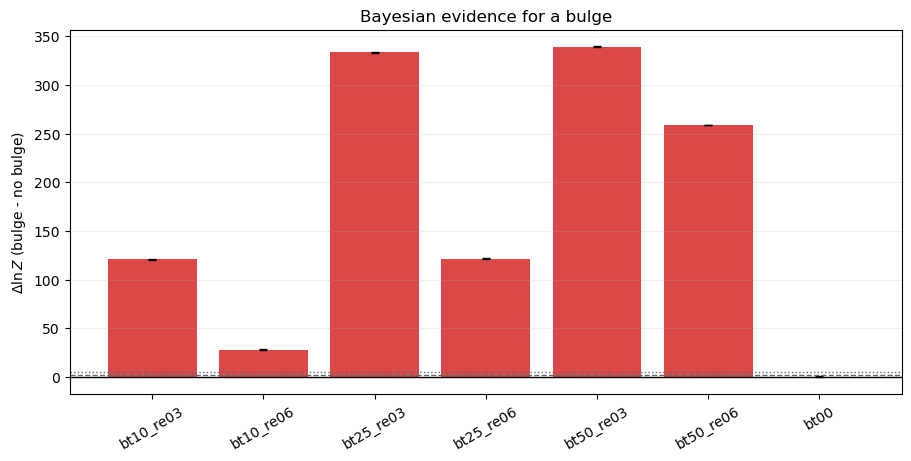

saved evidence diagnostic: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/stage4/results/figures/evidence_bulge_comparison.pdf
saved Dynesty diagnostics: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/stage4/results/figures/bt25_re06/no_bulge
saved Dynesty diagnostics: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/stage4/results/figures/bt25_re06/bulge
saved Dynesty diagnostics: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/stage4/results/figures/bt10_re06/no_bulge
saved Dynesty diagnostics: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/stage4/results/figures/bt10_re06/bulge
saved Dynesty diagnostics: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/stage4/results/figures/bt00/bulge
saved Dynesty diagnostics: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/stage4/results/figures/bt00/no_bulge
saved Dynesty diagnostics: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/stage4/res

In [7]:
FULL_RESULTS = (
    len(RESULTS) == len(CASES)
    and all(set(result) == {'no_bulge', 'bulge'} for result in RESULTS.values())
)
if FULL_RESULTS:
    rows = []
    for case in CASES:
        no_bulge = RESULTS[case['name']]['no_bulge']
        bulge = RESULTS[case['name']]['bulge']
        rows.append((
            case['name'], no_bulge['logz'], bulge['logz'],
            bulge['logz'] - no_bulge['logz'],
            np.hypot(no_bulge['logzerr'], bulge['logzerr']),
        ))
    EVIDENCE_TABLE = Table(
        rows=rows,
        names=(
            'case', 'lnZ no bulge', 'lnZ bulge', 'Delta lnZ',
            'Delta lnZ numerical error',
        ),
    )
    for name in EVIDENCE_TABLE.colnames[1:]:
        EVIDENCE_TABLE[name].format = '.3f'
    display(EVIDENCE_TABLE)

    fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
    delta = np.asarray(EVIDENCE_TABLE['Delta lnZ'])
    error = np.asarray(EVIDENCE_TABLE['Delta lnZ numerical error'])
    colors = [
        'tab:blue' if value < 2.5 else
        'tab:orange' if value < 5.0 else 'tab:red'
        for value in delta
    ]
    positions = np.arange(len(CASES))
    ax.bar(positions, delta, yerr=error, color=colors, alpha=0.85, capsize=3)
    ax.axhline(0, color='black', lw=1)
    ax.axhline(2.5, color='0.4', lw=1, ls='--')
    ax.axhline(5.0, color='0.4', lw=1, ls=':')
    ax.set_xticks(positions, [case['name'] for case in CASES], rotation=30)
    ax.set_ylabel(r'$\Delta\ln Z$ (bulge - no bulge)')
    ax.set_title('Bayesian evidence for a bulge')
    ax.grid(axis='y', alpha=0.2)
    evidence_path = FIGURE_DIR / 'evidence_bulge_comparison.pdf'
    fig.savefig(evidence_path, bbox_inches='tight')
    plt.show()
    print(f'saved evidence diagnostic: {evidence_path}')

CASE_BY_NAME = {case['name']: case for case in CASES}
for case_name, model_results in RESULTS.items():
    for model_name, result in model_results.items():
        directory = FIGURE_DIR / case_name / model_name
        directory.mkdir(parents=True, exist_ok=True)
        # Complex-Gaussian normalization makes absolute ln Z large and
        # positive; logplot=False exponentiates it and overflows.
        fig, _ = dyplot.runplot(result['results'], logplot=True)
        fig.savefig(directory / 'dynesty_runplot.pdf', bbox_inches='tight')
        plt.close(fig)
        labels = MODEL_FREE_NAMES[model_name]
        # 正解値を赤線で重ねる。bt00のbulge半径はNaNなので線は描かれない。
        case_truth = fmc.truth_parameters(CASE_BY_NAME[case_name], TRUTH_CONFIG)
        truths = [getattr(case_truth, name) for name in labels]
        fig, _ = dyplot.cornerplot(
            result['results'], labels=labels, truths=truths,
            truth_color='tab:red', show_titles=True,
        )
        fig.savefig(directory / 'dynesty_cornerplot.pdf', bbox_inches='tight')
        plt.close(fig)
        print(f'saved Dynesty diagnostics: {directory}')


bt25_re03 と bt25_re03 で ΔlnZ = ΔChi^2 / 2 がほぼ変わらないのは、おそらく分解能より細かい構造なので Bulge+Disk を Disk onlyで説明しやすいからかな？

## Best-fit channel diagnostics

Maximum-likelihood visibility modelを観測と同じuv sampling・natural weightでdirty image化する。

In [8]:
def dirty_cube(flat_visibilities, name):
    """Selected visibility vectorをfitと同じuv点・weightでdirty image化する。"""
    mock_entry = MOCKS[name]
    uv = load_processed_uv(mock_entry['path'], sort_channels_by_velocity=True)
    context = mock_entry['observation']
    sigma = mock_entry['observation'].sigma
    cube = np.empty((context.nchan, *MODEL.img_shape), dtype=float)
    beam = np.empty_like(cube)
    for channel, output_slice in enumerate(context.slices):
        selected = ~context.flag[channel]
        weight = 1.0 / sigma[output_slice]**2
        cube[channel], beam[channel] = vis_to_image_finufft_type3(
            uv.uvw_lam[0, channel, selected],
            uv.uvw_lam[1, channel, selected],
            flat_visibilities[output_slice], weight,
            MODEL.xx_img, MODEL.yy_img,
            eps=float(uv_cfg['finufft_tolerance']),
        )
    return cube, beam


def save_channel_diagnostics():
    rows = []
    image_extent = [
        MODEL.xx_img.min(), MODEL.xx_img.max(),
        MODEL.yy_img.min(), MODEL.yy_img.max(),
    ]
    source_extent = [
        MODEL.xx_src.min(), MODEL.xx_src.max(),
        MODEL.yy_src.min(), MODEL.yy_src.max(),
    ]
    for case in CASES:
        name = case['name']
        mock_entry = MOCKS[name]
        data = mock_entry['observation'].data
        sigma = mock_entry['observation'].sigma
        observed_dirty, _ = dirty_cube(data, name)
        noise_dirty, _ = dirty_cube(data - mock_entry['signal_data'], name)
        noise_rms = np.asarray([
            mad_std(channel, ignore_nan=True) for channel in noise_dirty
        ])
        fallback_rms = np.std(noise_dirty, axis=(1, 2))
        noise_rms = np.where(
            np.isfinite(noise_rms) & (noise_rms > 0), noise_rms, fallback_rms,
        )

        for model_name in ('no_bulge', 'bulge'):
            result = RESULTS[name][model_name]
            best = result['best_parameters']
            # Best-fit lensのcritical lines/causticsを白線で重ねる（全channel共通）。
            critical_lines, caustics = MODEL.critical_lines_and_caustics(best)
            best_visibilities = MODEL.make_visibilities(
                best, mock_entry['observation'],
                scale=mock_entry['flux_scale'],
            )
            model_dirty, _ = dirty_cube(best_visibilities, name)
            residual_dirty = observed_dirty - model_dirty
            residual_sigma = residual_dirty / noise_rms[:, None, None]
            source = MODEL.make_intrinsic_cube(best)

            visibility_chi2 = float(np.sum(
                np.abs((data - best_visibilities) / sigma)**2
            ))
            dof = 2 * data.size - len(MODEL_FREE_NAMES[model_name])
            reduced_chi2 = visibility_chi2 / dof
            rows.append((name, model_name, visibility_chi2, dof, reduced_chi2))

            directory = FIGURE_DIR / name / model_name
            directory.mkdir(parents=True, exist_ok=True)
            n_channels = MODEL.nchan
            fig, axes = plt.subplots(
                n_channels, 4, figsize=(8.5, 1.65 * n_channels), squeeze=False,
            )
            fig.subplots_adjust(wspace=0.02, hspace=0.02, top=0.975)
            image_vmin = -2.0 * float(np.median(noise_rms))
            image_vmax = 0.9 * max(
                float(np.nanmax(observed_dirty)), float(np.nanmax(model_dirty)),
            )
            source_vmax = float(np.nanmax(source))

            for channel, velocity_kms in enumerate(MODEL.vchan_kms):
                panels = (
                    (observed_dirty[channel], cm.roma_r, image_vmin, image_vmax, image_extent),
                    (model_dirty[channel], cm.roma_r, image_vmin, image_vmax, image_extent),
                    (residual_dirty[channel], cm.roma_r, image_vmin, image_vmax, image_extent),
                    (source[channel], cm.roma_r, 0.0, source_vmax, source_extent),
                )
                for column, (panel, cmap, vmin, vmax, extent) in enumerate(panels):
                    axes[channel, column].imshow(
                        panel, origin='lower', extent=extent,
                        cmap=cmap, vmin=vmin, vmax=vmax,
                    )
                    axes[channel, column].set_xticks([])
                    axes[channel, column].set_yticks([])
                observed_snr = observed_dirty[channel] / noise_rms[channel]
                model_snr = model_dirty[channel] / noise_rms[channel]
                for column, snr_map in ((0, observed_snr), (1, model_snr)):
                    peak = float(np.nanmax(snr_map))
                    if peak >= 8.0:
                        levels = [level for level in (8.0, 16.0, 32.0) if level <= peak]
                        axes[channel, column].contour(
                            snr_map, levels=levels, colors='black',
                            linewidths=0.25, alpha=0.55,
                            origin='lower', extent=image_extent,
                        )
                residual_levels = [
                    level for level in (-5.0, -4.0, -3.0, 3.0, 4.0, 5.0)
                    if np.nanmin(residual_sigma[channel]) <= level <= np.nanmax(residual_sigma[channel])
                ]
                if residual_levels:
                    axes[channel, 2].contour(
                        residual_sigma[channel], levels=residual_levels,
                        colors='black', linewidths=0.25, alpha=0.55,
                        origin='lower', extent=image_extent,
                    )
                for column in (0, 1, 2):
                    for curve in critical_lines:
                        axes[channel, column].plot(
                            curve[:, 0], curve[:, 1],
                            color='white', lw=0.4, alpha=0.9,
                        )
                    axes[channel, column].set_xlim(image_extent[0], image_extent[1])
                    axes[channel, column].set_ylim(image_extent[2], image_extent[3])
                for curve in caustics:
                    axes[channel, 3].plot(
                        curve[:, 0], curve[:, 1],
                        color='white', lw=0.4, alpha=0.9,
                    )
                axes[channel, 3].set_xlim(source_extent[0], source_extent[1])
                axes[channel, 3].set_ylim(source_extent[2], source_extent[3])
                axes[channel, 0].text(
                    0.03, 0.93,
                    f'{velocity_kms:+.0f} km/s; Peak S/N={np.nanmax(observed_snr):.1f}',
                    transform=axes[channel, 0].transAxes,
                    color='white', fontsize=7, va='top',
                )

            titles = (
                'Truth / observed dirty', 'Best-fit model dirty',
                'Residual dirty', 'Best-fit intrinsic source',
            )
            for axis_object, title in zip(axes[0], titles, strict=True):
                axis_object.set_title(title, fontsize=9)
            fig.suptitle(
                f'{name} — {model_name}; visibility reduced $\\chi^2$={reduced_chi2:.3f}',
                fontsize=10, y=0.995,
            )
            output_path = directory / 'all_channel_dirty_comparison.pdf'
            fig.savefig(output_path, bbox_inches='tight', pad_inches=0.03)
            plt.close(fig)
            print(f'saved {output_path.relative_to(EXAMPLE_DIR)}')

    diagnostics = Table(
        rows=rows,
        names=('case', 'model', 'visibility_chi2', 'dof', 'reduced_chi2'),
    )
    for name in diagnostics.colnames[2:]:
        diagnostics[name].format = '.5g'
    diagnostics_path = OUTPUT_DIR / 'fit_diagnostics.csv'
    diagnostics.write(diagnostics_path, format='ascii.csv', overwrite=True)
    display(diagnostics)
    print(f'saved {diagnostics_path.relative_to(EXAMPLE_DIR)}')
    return diagnostics


if FULL_RESULTS:
    FIT_DIAGNOSTICS = save_channel_diagnostics()
else:
    print('channel diagnostics skipped: all case/model results are required')


saved output/stage4/results/figures/bt10_re03/no_bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt10_re03/bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt10_re06/no_bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt10_re06/bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt25_re03/no_bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt25_re03/bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt25_re06/no_bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt25_re06/bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt50_re03/no_bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt50_re03/bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt50_re06/no_bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt50_re06/b

case,model,visibility_chi2,dof,reduced_chi2
str9,str8,float64,int64,float64
bt10_re03,no_bulge,3.5904e+05,3.5564e+05,1.0096
bt10_re03,bulge,3.588e+05,3.5564e+05,1.0089
bt10_re06,no_bulge,3.5905e+05,3.5564e+05,1.0096
bt10_re06,bulge,3.59e+05,3.5564e+05,1.0095
bt25_re03,no_bulge,3.5975e+05,3.5564e+05,1.0116
bt25_re03,bulge,3.5909e+05,3.5564e+05,1.0097
bt25_re06,no_bulge,3.5564e+05,3.5564e+05,1
bt25_re06,bulge,3.554e+05,3.5564e+05,0.99934
bt50_re03,no_bulge,3.6267e+05,3.5564e+05,1.0198


saved output/stage4/results/fit_diagnostics.csv


## Rotation curves with posterior uncertainty

Maximum-likelihood sampleをbest-fit線として表示し、joint weighted posteriorを物理的回転曲線へ伝播した
16–84 percentileを帯で示す。総回転曲線のケース比較と、bulge/no-bulge fit別の成分分解を保存する。


In [9]:
ROTATION_COMPONENTS = ('total', 'disk', 'bulge', 'halo')


def posterior_rotation_curve_intervals(case, model_name, max_samples=2000):
    """Joint Dynesty posteriorを各mass componentの回転曲線へ伝播する。"""
    result = RESULTS[case['name']][model_name]
    samples = np.asarray(result['results'].samples)
    weights = np.asarray(result['weights'], dtype=float)
    weights /= weights.sum()
    sample_count = min(max_samples, samples.shape[0])
    rng = np.random.default_rng(fmc.stable_task_seed(case['name'], model_name) + 104729)
    indices = rng.choice(
        samples.shape[0], size=sample_count, replace=True, p=weights,
    )
    layout = PARAMETER_LAYOUTS[(case['name'], model_name)]
    curves = {
        component: np.empty((sample_count, MODEL.radius_kpc.size), dtype=float)
        for component in ROTATION_COMPONENTS
    }
    for row, sample_index in enumerate(indices):
        curve = MODEL.rotation_curve(layout.decode(samples[sample_index]))
        for component in ROTATION_COMPONENTS:
            curves[component][row] = curve[f'{component}_kms']
    return {
        component: np.percentile(values, (16.0, 50.0, 84.0), axis=0)
        for component, values in curves.items()
    }


if FULL_RESULTS:
    ROTATION_INTERVALS = {
        (case['name'], model_name): posterior_rotation_curve_intervals(case, model_name)
        for case in CASES for model_name in ('no_bulge', 'bulge')
    }

    ncols = 3
    nrows = int(np.ceil(len(CASES) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(14, 4 * nrows), sharex=True, sharey=True,
        squeeze=False, constrained_layout=True,
    )
    fit_styles = {
        'no_bulge': dict(color='tab:blue', lw=2.2, ls='--', label='no-bulge ML fit'),
        'bulge': dict(color='tab:red', lw=1.8, ls='-.', label='bulge ML fit'),
    }
    for ax, case in zip(axes.flat, CASES):
        truth_curve = MODEL.rotation_curve(fmc.truth_parameters(case, TRUTH_CONFIG))
        ax.plot(
            MODEL.radius_kpc, truth_curve['total_kms'],
            color='black', lw=2.2, label='truth',
        )
        for model_name in ('no_bulge', 'bulge'):
            lower, _, upper = ROTATION_INTERVALS[(case['name'], model_name)]['total']
            color = fit_styles[model_name]['color']
            ax.fill_between(MODEL.radius_kpc, lower, upper, color=color, alpha=0.14, linewidth=0)
            best = MODEL.rotation_curve(RESULTS[case['name']][model_name]['best_parameters'])
            ax.plot(MODEL.radius_kpc, best['total_kms'], **fit_styles[model_name])
        title = (
            'B/T=0 (no bulge)' if case['bulge_to_total'] == 0 else
            f"B/T={case['bulge_to_total']:.2f}, Re={case['bulge_effective_radius_kpc']:.1f} kpc"
        )
        ax.set_title(title)
        ax.grid(alpha=0.2)
    for ax in axes.flat[len(CASES):]:
        ax.set_visible(False)
    for ax in axes[:, 0]:
        ax.set_ylabel(r'Circular velocity / km s$^{-1}$')
    for ax in axes[-1]:
        ax.set_xlabel('Radius / kpc')
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='outside upper center', ncol=3, frameon=False)
    total_path = FIGURE_DIR / 'rotation_curves_total.pdf'
    fig.savefig(total_path, bbox_inches='tight')
    plt.close(fig)
    print(f'saved {total_path.relative_to(EXAMPLE_DIR)}')

    component_colors = {
        'total': 'black', 'disk': 'tab:blue',
        'bulge': 'tab:orange', 'halo': 'tab:green',
    }
    fig, axes = plt.subplots(
        len(CASES), 2, figsize=(12, 3.2 * len(CASES)),
        sharex=True, sharey=True, squeeze=False, constrained_layout=True,
    )
    for row, case in enumerate(CASES):
        truth_curve = MODEL.rotation_curve(fmc.truth_parameters(case, TRUTH_CONFIG))
        for column, model_name in enumerate(('no_bulge', 'bulge')):
            ax = axes[row, column]
            best_curve = MODEL.rotation_curve(RESULTS[case['name']][model_name]['best_parameters'])
            intervals = ROTATION_INTERVALS[(case['name'], model_name)]
            for component, color in component_colors.items():
                key = f'{component}_kms'
                lower, _, upper = intervals[component]
                ax.fill_between(
                    MODEL.radius_kpc, lower, upper, color=color, alpha=0.10, linewidth=0,
                )
                ax.plot(
                    MODEL.radius_kpc, truth_curve[key], color=color, lw=1.8,
                    label=component if row == 0 and column == 0 else None,
                )
                ax.plot(
                    MODEL.radius_kpc, best_curve[key], color=color, lw=1.2, ls='--',
                )
            ax.grid(alpha=0.2)
            if column == 0:
                ax.set_ylabel(f"{case['name']}\nCircular velocity / km s$^{{-1}}$")
    axes[0, 0].set_title('No-bulge model')
    axes[0, 1].set_title('Bulge model')
    for ax in axes[-1]:
        ax.set_xlabel('Radius / kpc')
    axes[0, 0].legend(loc='upper right', ncol=2, fontsize=7, frameon=False)
    fig.suptitle(
        'Solid: truth; dashed: maximum likelihood; shaded: posterior 16-84%',
        fontsize=11,
    )
    component_path = FIGURE_DIR / 'rotation_curves_components.pdf'
    fig.savefig(component_path, bbox_inches='tight')
    plt.close(fig)
    print(f'saved {component_path.relative_to(EXAMPLE_DIR)}')
else:
    print('rotation-curve diagnostics skipped: all case/model results are required')


saved output/stage4/results/figures/rotation_curves_total.pdf
saved output/stage4/results/figures/rotation_curves_components.pdf


### 結果よく収束したけど、なぜ $R_e=0.3$ kpcが決まるのか？
natural weightのdirty beamは FWHM=0.277" ~ 1.58 kpc  
$\mu_{\rm average} = 9.4$ なので、実効的な分解能は $1.58 / \sqrt{9.4}\sim 0.52$ kpc  
今はcoreなしSIE（convergence=0）を使ってるので、像の拡大は接線方向のみ --> 接線方向には $\sim 0.2$ kpcなのでギリ分解できるかもね程度。  

考えられる要因
- そもそも今はバルジからの光を見ているのではなくて、運動を見ている。力学的な影響圏は Re より外まで伸びる。Hernquistの$v^2$はR=a≈Re/1.8で最大となり外側でKepler的に落ちる
  - 実際 `bt50_re03` のケースでは、$v_{\rm bulge} > v_{\rm disk}$ となるのは R < 2.25 kpc --> Re=0.3の7倍以上外側まで
  - R_e=0.3 vs 0.6（同じB/T=0.5）の$v_{\rm circ}$差は R=0.5 kpcで98 km/s、R=1 kpcでも49 km/s — channel幅25 km/s、σ₀=30 km/sに対して2〜4 channel分の差
  - $\Delta lnZ(re03) > \Delta lnZ(re06)$ であ李、evidenceにも表れている 
- もちろん、パラメトリックな理想系なので一番楽観的な見方ではある